In [ ]:
# ── Cell 1: Mount Drive ────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Cell 2: Config ─────────────────────────────────────────────────────────
from pathlib import Path
import torch

# ── Paths ──────────────────────────────────────────────────────────────────
SAVE_PATH  = Path("/content/drive/MyDrive/SER_Project")
PICKLE_SRC = str(SAVE_PATH / "src_audio_4s.pkl")
PICKLE_TGT = str(SAVE_PATH / "tgt_audio_4s.pkl")

# ── Audio ──────────────────────────────────────────────────────────────────
SAMPLE_RATE   = 16000
DURATION      = 4.5
TARGET_LENGTH = int(SAMPLE_RATE * DURATION)

# ── Training (defaults, Optuna will tune these) ────────────────────────────
BATCH_SIZE     = 16
EPOCHS         = 50
PATIENCE       = 10
SEED           = 42
LR_HUBERT      = 1e-5
LR_HEAD        = 1e-3
LAMBDA_SUPCON  = 0.3
SUPCON_TEMP    = 0.07
KEEP_RATE      = 0.7
UNFREEZE_N     = 4

# ── Dataset ────────────────────────────────────────────────────────────────
NUM_CLASSES  = 7
CLASS_LABELS = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB


In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 27.4 MB/s eta 0:00:00


In [ ]:
# ── Cell 3: Imports & Helpers ──────────────────────────────────────────────
import os, random, warnings, pickle, json
warnings.filterwarnings("ignore")

import numpy as np
import librosa
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from transformers import HubertModel, Wav2Vec2FeatureExtractor

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
import optuna

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── Seeds ──────────────────────────────────────────────────────────────────
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

# ── Label encoder ──────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(CLASS_LABELS)

# ── Dataset class ──────────────────────────────────────────────────────────
class SERDataset(Dataset):
    def __init__(self, audio_list, label_list, feature_extractor):
        self.audio             = audio_list
        self.labels            = torch.tensor(le.transform(label_list), dtype=torch.long)
        self.feature_extractor = feature_extractor

    def __len__(self):
        return len(self.audio)

    def __getitem__(self, idx):
        inputs = self.feature_extractor(
            self.audio[idx],
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
            padding=True
        )
        return inputs.input_values.squeeze(0), self.labels[idx]

# ── HuBERT processor ───────────────────────────────────────────────────────
print("Loading HuBERT processor...")
hubert_processor = Wav2Vec2FeatureExtractor.from_pretrained(
    "facebook/hubert-large-ls960-ft"
)
print("All imports and helpers ready.")

Loading HuBERT processor...


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

All imports and helpers ready.


In [ ]:
# ── Cell 4: Data Loading ───────────────────────────────────────────────────
print("Loading from pickle...")
with open(PICKLE_SRC, "rb") as f:
    src_audio, src_labels = pickle.load(f)
with open(PICKLE_TGT, "rb") as f:
    tgt_audio, tgt_labels = pickle.load(f)
print(f"Source: {len(src_audio)}, Target: {len(tgt_audio)}")

# Split TESS
tgt_labels_enc = le.transform(tgt_labels)
tgt_adapt_audio, tgt_test_audio, tgt_adapt_labels, tgt_test_labels = train_test_split(
    tgt_audio, tgt_labels,
    test_size=0.2, random_state=SEED,
    stratify=tgt_labels_enc
)

# Dataloaders
src_dataset       = SERDataset(src_audio,       src_labels,       hubert_processor)
tgt_adapt_dataset = SERDataset(tgt_adapt_audio, tgt_adapt_labels, hubert_processor)
tgt_test_dataset  = SERDataset(tgt_test_audio,  tgt_test_labels,  hubert_processor)

src_loader       = DataLoader(src_dataset,       batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
tgt_adapt_loader = DataLoader(tgt_adapt_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
tgt_test_loader  = DataLoader(tgt_test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"\nSource       : {len(src_audio)} samples, {len(src_loader)} batches")
print(f"Target adapt : {len(tgt_adapt_audio)} samples, {len(tgt_adapt_loader)} batches")
print(f"Target test  : {len(tgt_test_audio)} samples, {len(tgt_test_loader)} batches")

Loading from pickle...
Source: 7488, Target: 5600

Source       : 7488 samples, 468 batches
Target adapt : 4480 samples, 280 batches
Target test  : 1120 samples, 70 batches


In [ ]:
# ── Cell 5: DPPMI + SupCon Loss ────────────────────────────────────────────
class DPPMIDropout(nn.Module):
    def __init__(self, keep_rate=0.7):
        super().__init__()
        self.keep_rate = keep_rate

    def forward(self, x):
        if not self.training:
            return x
        mean      = x.mean(dim=0, keepdim=True)
        variance  = ((x - mean) ** 2).mean(dim=0)
        mi_scores = variance / (variance.sum() + 1e-8)
        normed    = F.normalize(x, dim=0)
        sim       = normed.T @ normed
        mi_outer  = torch.outer(mi_scores, mi_scores)
        L         = mi_outer * sim
        scores    = torch.diag(L)
        n_keep    = max(1, int(self.keep_rate * x.shape[-1]))
        _, top_idx = torch.topk(scores, n_keep)
        mask = torch.zeros(x.shape[-1], device=x.device)
        mask[top_idx] = 1.0 / self.keep_rate
        return x * mask


class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device     = features.device
        batch_size = features.shape[0]
        features   = F.normalize(features, dim=1)
        sim_matrix = torch.matmul(features, features.T) / self.temperature
        sim_max, _ = torch.max(sim_matrix, dim=1, keepdim=True)
        sim_matrix = sim_matrix - sim_max.detach()
        labels     = labels.contiguous().view(-1, 1)
        mask_pos   = torch.eq(labels, labels.T).float().to(device)
        mask_self  = torch.eye(batch_size, device=device)
        mask_pos   = mask_pos - mask_self
        exp_sim    = torch.exp(sim_matrix) * (1 - mask_self)
        log_prob   = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)
        num_pos    = mask_pos.sum(dim=1)
        num_pos    = torch.where(num_pos == 0, torch.ones_like(num_pos), num_pos)
        mean_log_prob_pos = (mask_pos * log_prob).sum(dim=1) / num_pos
        return -mean_log_prob_pos.mean()

print("DPPMI and SupCon ready.")

DPPMI and SupCon ready.


In [ ]:
# ── Cell 6: Model ─────────────────────────────────────────────────────────
class SERModel(nn.Module):
    def __init__(self, num_classes, keep_rate=0.7, unfreeze_last_n=4):
        super().__init__()

        self.hubert = HubertModel.from_pretrained("facebook/hubert-large-ls960-ft")

        for param in self.hubert.parameters():
            param.requires_grad = False

        n_layers = len(self.hubert.encoder.layers)
        for i, layer in enumerate(self.hubert.encoder.layers):
            if i >= n_layers - unfreeze_last_n:
                for param in layer.parameters():
                    param.requires_grad = True

        for param in self.hubert.encoder.layer_norm.parameters():
            param.requires_grad = True

        self.dppmi = DPPMIDropout(keep_rate=keep_rate)

        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def get_hubert_features(self, input_values):
        outputs = self.hubert(input_values)
        return outputs.last_hidden_state.mean(dim=1)

    def forward(self, input_values):
        embeddings = self.get_hubert_features(input_values)
        sparse     = self.dppmi(embeddings)
        logits     = self.classifier(sparse)
        return logits, embeddings


print("Model class ready.")

Model class ready.


In [ ]:
# ── Cell 7: Training & Evaluation Functions ────────────────────────────────
def build_model_and_optimizer(keep_rate=0.7, unfreeze_n=4,
                               lr_hubert=1e-5, lr_head=1e-3):
    m = SERModel(num_classes=NUM_CLASSES, keep_rate=keep_rate,
                 unfreeze_last_n=unfreeze_n).to(DEVICE)
    opt = AdamW([
        {"params": [p for p in m.hubert.parameters() if p.requires_grad], "lr": lr_hubert},
        {"params": m.dppmi.parameters(),      "lr": lr_head},
        {"params": m.classifier.parameters(), "lr": lr_head}
    ], weight_decay=1e-4)
    sch = ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=5)
    return m, opt, sch


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for input_values, labels in loader:
            input_values = input_values.float().to(DEVICE)
            logits, _    = model(input_values)
            preds        = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    return acc, all_preds, all_labels


def train_model(model, optimizer, scheduler, supcon_loss_fn=None,
                lambda_supcon=0.3, label="Model", epochs=EPOCHS,
                patience=PATIENCE, save_name="best_model.pt"):
    criterion      = nn.CrossEntropyLoss()
    best_acc       = 0
    patience_count = 0
    history = {"ce_loss": [], "supcon_loss": [], "src_acc": [], "tgt_acc": []}

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"{'Ep':>4} | {'CE':>8} | {'SupCon':>8} | {'Src Acc':>8} | {'Tgt Acc':>8}")
    print("-"*55)

    tgt_iter = iter(tgt_adapt_loader)

    for epoch in range(epochs):
        model.train()
        epoch_ce, epoch_supcon = [], []

        for src_inputs, src_labels in src_loader:
            src_inputs = src_inputs.float().to(DEVICE)
            src_labels = src_labels.to(DEVICE)

            try:
                tgt_inputs, tgt_labels_batch = next(tgt_iter)
            except StopIteration:
                tgt_iter = iter(tgt_adapt_loader)
                tgt_inputs, tgt_labels_batch = next(tgt_iter)
            tgt_inputs       = tgt_inputs.float().to(DEVICE)
            tgt_labels_batch = tgt_labels_batch.to(DEVICE)

            optimizer.zero_grad()

            src_logits, src_emb = model(src_inputs)
            _,          tgt_emb = model(tgt_inputs)

            ce_loss = criterion(src_logits, src_labels)

            if supcon_loss_fn is not None:
                sc_loss    = supcon_loss_fn(src_emb, src_labels)
                total_loss      = ce_loss + lambda_supcon * sc_loss
            else:
                sc_loss    = torch.tensor(0.0)
                total_loss = ce_loss

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_ce.append(ce_loss.item())
            epoch_supcon.append(sc_loss.item())

        # Evaluate target every epoch, source every 5
        tgt_acc, _, _ = evaluate(model, tgt_test_loader)
        src_acc, _, _ = evaluate(model, src_loader)

        scheduler.step(tgt_acc)

        history["ce_loss"].append(np.mean(epoch_ce))
        history["supcon_loss"].append(np.mean(epoch_supcon))
        history["src_acc"].append(src_acc)
        history["tgt_acc"].append(tgt_acc)

        print(f"{epoch+1:>4} | "
              f"{np.mean(epoch_ce):>8.4f} | "
              f"{np.mean(epoch_supcon):>8.4f} | "
              f"{src_acc*100:>7.2f}% | "
              f"{tgt_acc*100:>7.2f}%")

        # Early stopping on raw tgt_acc (no smooth)
        if tgt_acc > best_acc:
            best_acc       = tgt_acc
            patience_count = 0
            torch.save(model.state_dict(), SAVE_PATH / save_name)
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    print(f"\nBest Target Accuracy: {best_acc*100:.2f}%")
    return history, best_acc

print("Training functions ready.")

Training functions ready.


In [ ]:
# ── Cell 8: Optuna Hyperparameter Tuning ──────────────────────────────────
import gc

def objective(trial):
    # Hyperparameters to tune
    lr_hubert     = trial.suggest_float("lr_hubert",     1e-6, 1e-4, log=True)
    lr_head       = trial.suggest_float("lr_head",       1e-4, 1e-2, log=True)
    lambda_supcon = trial.suggest_float("lambda_supcon", 0.1,  1.0)
    supcon_temp   = trial.suggest_float("supcon_temp",   0.05, 0.2)
    keep_rate     = trial.suggest_float("keep_rate",     0.5,  0.9)
    unfreeze_n    = trial.suggest_int("unfreeze_n",      2,    8)

    # Build model
    model, optimizer, scheduler = build_model_and_optimizer(
        keep_rate=keep_rate, unfreeze_n=unfreeze_n,
        lr_hubert=lr_hubert, lr_head=lr_head
    )
    supcon_fn = SupConLoss(temperature=supcon_temp).to(DEVICE)

    # Short run — 15 epochs per trial to save compute
    _, best_acc = train_model(
        model, optimizer, scheduler,
        supcon_loss_fn=supcon_fn,
        lambda_supcon=lambda_supcon,
        label=f"Trial {trial.number}",
        epochs=15,
        patience=5,
        save_name=f"optuna_trial_{trial.number}.pt"
    )

    # Cleanup GPU memory
    del model, optimizer, scheduler, supcon_fn
    gc.collect()
    torch.cuda.empty_cache()

    return best_acc


# Run Optuna — 15 trials
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f"\n{'='*50}")
print(f"Best trial accuracy : {study.best_value*100:.2f}%")
print(f"Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"{'='*50}")

# Save best params
with open(SAVE_PATH / "best_params.json", "w") as f:
    json.dump(study.best_params, f, indent=2)
print("Best params saved.")

[I 2026-06-30 23:08:21,044] A new study created in memory with name: no-name-3af6ac7d-90ce-4e2f-ba8f-3a3f5156cbbc


  0%|          | 0/15 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

...


  Trial 1
  Ep |       CE |   SupCon |  Src Acc |  Tgt Acc |   Smooth
------------------------------------------------------------
   1 |   1.7503 |   3.4154 |    0.00% |   34.82% |   34.82%
   2 |   1.4539 |   3.1499 |    0.00% |   56.79% |   45.80%
   3 |   1.2643 |   3.0287 |    0.00% |   69.73% |   53.78%
   4 |   1.1006 |   2.8876 |    0.00% |   78.39% |   59.93%
   5 |   0.9741 |   2.7673 |   73.00% |   78.30% |   63.61%
   6 |   0.8719 |   2.7117 |   73.00% |   80.27% |   72.70%
   7 |   0.7975 |   2.6271 |   73.00% |   79.73% |   77.29%
   8 |   0.7643 |   2.5991 |   73.00% |   84.20% |   80.18%
   9 |   0.6854 |   2.5156 |   73.00% |   87.77% |   82.05%
  10 |   0.6600 |   2.4866 |   81.54% |   86.96% |   83.79%
  11 |   0.6107 |   2.4114 |   81.54% |   93.75% |   86.48%
  12 |   0.5993 |   2.3867 |   81.54% |   94.91% |   89.52%
  13 |   0.5558 |   2.3402 |   81.54% |   96.96% |   92.07%
  14 |   0.5313 |   2.3052 |   81.54% |   96.25% |   93.77%
  15 |   0.5195 |   2.2532 |

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Trial 2
  Ep |       CE |   SupCon |  Src Acc |  Tgt Acc |   Smooth
------------------------------------------------------------
   1 |   1.9340 |   3.5286 |    0.00% |   16.61% |   16.61%
   2 |   1.8730 |   3.4672 |    0.00% |   20.80% |   18.71%
   3 |   1.8612 |   3.4372 |    0.00% |   23.39% |   20.27%
   4 |   1.8477 |   3.4293 |    0.00% |   18.75% |   19.89%
   5 |   1.8100 |   3.4180 |   27.48% |   15.27% |   18.96%
[W 2026-07-01 01:45:28,543] Trial 2 failed with parameters: {'lr_hubert': 2.731297674792032e-06, 'lr_head': 0.003797013139258489, 'lambda_supcon': 0.805545411534283, 'supcon_temp': 0.14318672317535208, 'keep_rate': 0.6305386283929721, 'unfreeze_n': 6} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_2772/628204090.py", line 21, in objec

KeyboardInterrupt: 

# Interrupted Optuna because already found best parameters to save computing power

In [ ]:
best_params = {
    "lr_hubert":     3.6864090428834625e-05,
    "lr_head":       0.00014333499770856763,
    "lambda_supcon": 0.10456136669476407,
    "supcon_temp":   0.07885172567588086,
    "keep_rate":     0.8676377934394799,
    "unfreeze_n":    6
}

import json
with open(SAVE_PATH / "best_params.json", "w") as f:
    json.dump(best_params, f, indent=2)
print("Best params saved:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Best params saved:
  lr_hubert: 3.6864090428834625e-05
  lr_head: 0.00014333499770856763
  lambda_supcon: 0.10456136669476407
  supcon_temp: 0.07885172567588086
  keep_rate: 0.8676377934394799
  unfreeze_n: 6


In [ ]:
BP = best_params

In [ ]:
# ── Cell 9: Run 1 — HuBERT Only ───────────────────────────────────────────
import IPython, gc
display(IPython.display.Javascript('''
function ClickConnect(){
    console.log("Keeping session alive");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)
'''))

class SERModelBaseline(nn.Module):
    """HuBERT only — no DPPMI, no SupCon."""
    def __init__(self, num_classes, unfreeze_last_n=6):
        super().__init__()
        self.hubert = HubertModel.from_pretrained("facebook/hubert-large-ls960-ft")
        for param in self.hubert.parameters():
            param.requires_grad = False
        n_layers = len(self.hubert.encoder.layers)
        for i, layer in enumerate(self.hubert.encoder.layers):
            if i >= n_layers - unfreeze_last_n:
                for param in layer.parameters():
                    param.requires_grad = True
        for param in self.hubert.encoder.layer_norm.parameters():
            param.requires_grad = True
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def get_hubert_features(self, input_values):
        outputs = self.hubert(input_values)
        return outputs.last_hidden_state.mean(dim=1)

    def forward(self, input_values):
        embeddings = self.get_hubert_features(input_values)
        logits     = self.classifier(embeddings)
        return logits, embeddings


model1 = SERModelBaseline(
    num_classes    = NUM_CLASSES,
    unfreeze_last_n = int(BP["unfreeze_n"])
).to(DEVICE)

opt1 = AdamW([
    {"params": [p for p in model1.hubert.parameters() if p.requires_grad],
     "lr": BP["lr_hubert"]},
    {"params": model1.classifier.parameters(), "lr": BP["lr_head"]}
], weight_decay=1e-4)
sch1 = ReduceLROnPlateau(opt1, mode="max", factor=0.5, patience=5)

hist1, acc1 = train_model(
    model1, opt1, sch1,
    supcon_loss_fn = None,
    label          = "HuBERT Only",
    save_name      = "best_hubert_only.pt"
)

# Evaluate and save
_, preds1, labels1 = evaluate(model1, tgt_test_loader)
np.save(SAVE_PATH / "preds_hubert_only.npy", np.array(preds1))
np.save(SAVE_PATH / "labels_test.npy",       np.array(labels1))

with open(SAVE_PATH / "hist_hubert_only.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in hist1.items()}, f)

with open(SAVE_PATH / "result_hubert_only.json", "w") as f:
    json.dump({"HuBERT Only": float(acc1)}, f, indent=2)

print(f"\nHuBERT Only: {acc1*100:.2f}%")
print("Saved.")

# Clear GPU
del model1, opt1, sch1
gc.collect()
torch.cuda.empty_cache()
print("GPU cleared.")

<IPython.core.display.Javascript object>

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  HuBERT Only
  Ep |       CE |   SupCon |  Src Acc |  Tgt Acc |   Smooth
------------------------------------------------------------
   1 |   1.7830 |   0.0000 |    0.00% |   17.50% |   17.50%
   2 |   1.4524 |   0.0000 |    0.00% |   28.39% |   22.95%
   3 |   1.2546 |   0.0000 |    0.00% |   33.04% |   26.31%
   4 |   1.0779 |   0.0000 |    0.00% |   49.55% |   32.12%
   5 |   0.9588 |   0.0000 |   66.81% |   54.11% |   36.52%
   6 |   0.8620 |   0.0000 |   66.81% |   51.61% |   43.34%
   7 |   0.8062 |   0.0000 |   66.81% |   52.32% |   48.13%
   8 |   0.7328 |   0.0000 |   66.81% |   55.98% |   52.71%
   9 |   0.7087 |   0.0000 |   66.81% |   58.57% |   54.52%
  10 |   0.6341 |   0.0000 |   81.42% |   57.77% |   55.25%
  11 |   0.6049 |   0.0000 |   81.42% |   56.52% |   56.23%
  12 |   0.5739 |   0.0000 |   81.42% |   52.86% |   56.34%
  13 |   0.5390 |   0.0000 |   81.42% |   57.32% |   56.61%
  14 |   0.5187 |   0.0000 |   81.42% |   46.07% |   54.11%
  15 |   0.4918 |   0.00

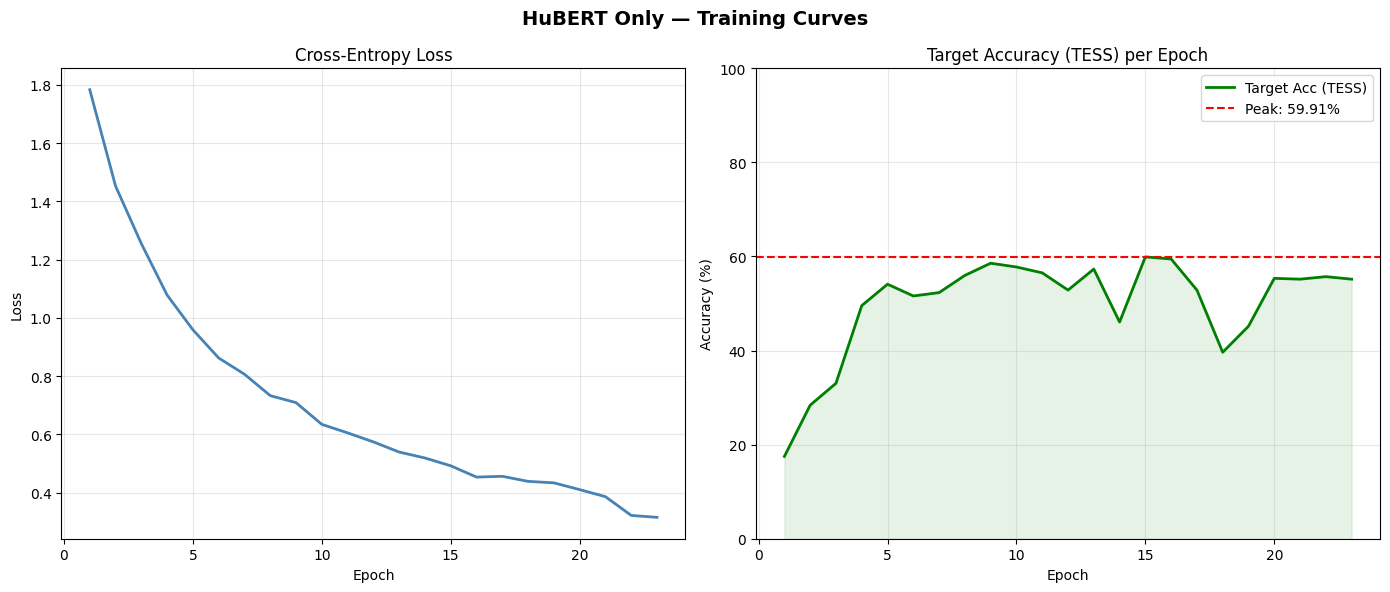

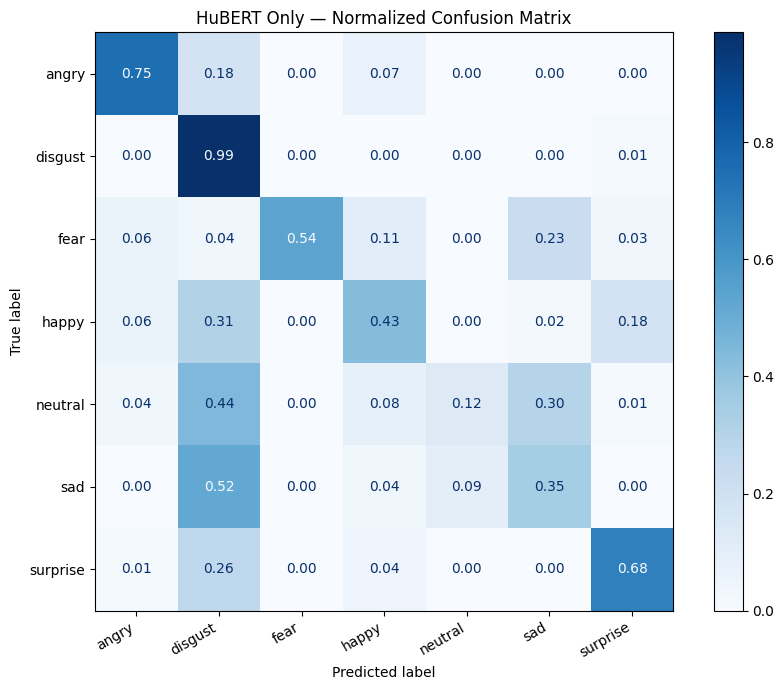

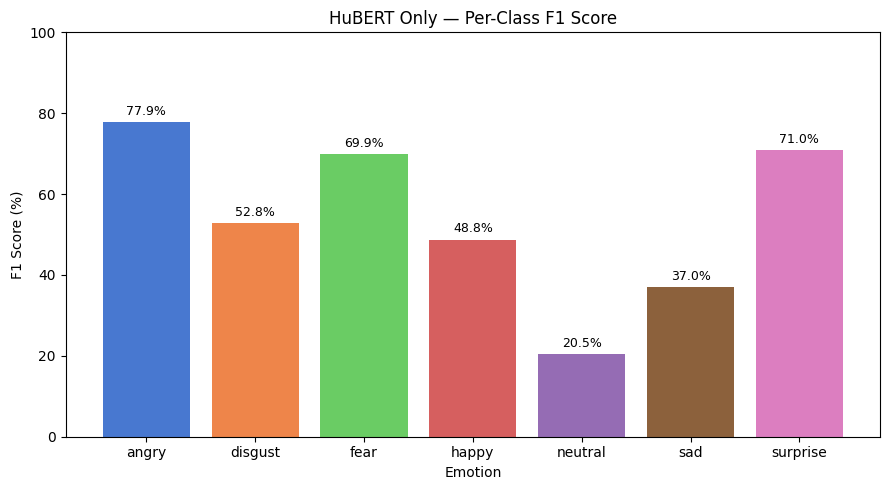

PDF saved: /content/drive/MyDrive/SER_Project/graphs_HuBERT_Only.pdf


In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

def save_run_graphs(history, preds, labels, run_name, best_acc, save_path):
    pdf_path = save_path / f"graphs_{run_name.replace(' ', '_')}.pdf"

    with PdfPages(pdf_path) as pdf:

        # Page 1: Training Curves
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle(f"{run_name} — Training Curves", fontsize=14, fontweight="bold")
        epochs = range(1, len(history["ce_loss"]) + 1)

        axes[0].plot(epochs, history["ce_loss"], color="steelblue", linewidth=2)
        axes[0].set_title("Cross-Entropy Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].grid(True, alpha=0.3)

        tgt = [a*100 for a in history["tgt_acc"]]
        axes[1].plot(epochs, tgt, color="green", linewidth=2, label="Target Acc (TESS)")
        axes[1].fill_between(epochs, tgt, alpha=0.1, color="green")
        axes[1].axhline(y=max(tgt), color="red", linestyle="--", linewidth=1.5,
                        label=f"Peak: {max(tgt):.2f}%")
        axes[1].set_title("Target Accuracy (TESS) per Epoch")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy (%)")
        axes[1].set_ylim(0, 100)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

        # Page 2: Confusion Matrix
        fig, ax = plt.subplots(figsize=(9, 7))
        cm = confusion_matrix(labels, preds, normalize="true")
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
        disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format=".2f")
        ax.set_title(f"{run_name} — Normalized Confusion Matrix")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

        # Page 3: Per-Class F1
        f1s = f1_score(labels, preds, average=None)
        fig, ax = plt.subplots(figsize=(9, 5))
        bars = ax.bar(CLASS_LABELS, f1s * 100, color=sns.color_palette("muted", NUM_CLASSES))
        ax.set_title(f"{run_name} — Per-Class F1 Score")
        ax.set_xlabel("Emotion")
        ax.set_ylabel("F1 Score (%)")
        ax.set_ylim(0, 100)
        for bar, f1 in zip(bars, f1s):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{f1*100:.1f}%", ha="center", va="bottom", fontsize=9)
        plt.tight_layout()
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

        # Page 4: Classification Report
        report = classification_report(labels, preds, target_names=CLASS_LABELS, digits=3)
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.axis("off")
        ax.text(0.01, 0.99, f"{run_name}\nClassification Report\n\n{report}",
                transform=ax.transAxes, fontsize=10,
                verticalalignment="top", fontfamily="monospace")
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.close()

    print(f"PDF saved: {pdf_path}")

# Generate graphs for HuBERT Only
save_run_graphs(hist1, preds1, labels1, "HuBERT Only", acc1, SAVE_PATH)

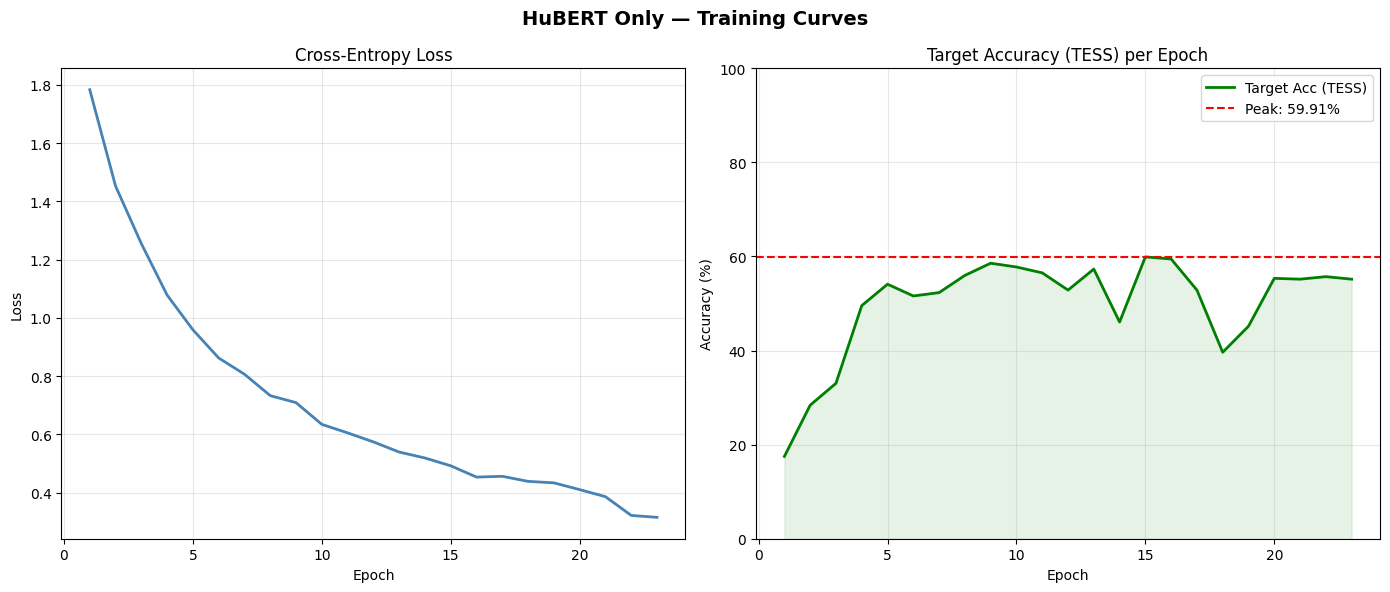

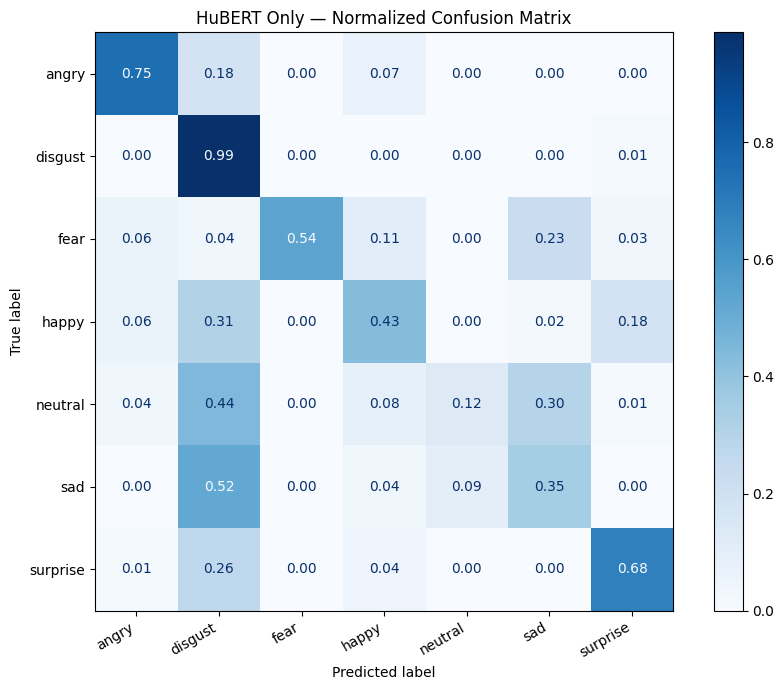

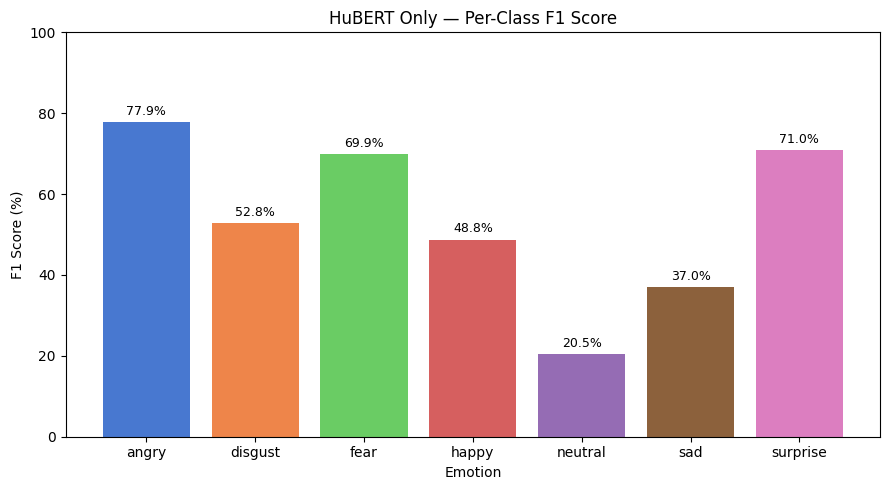

PDF saved: /content/drive/MyDrive/SER_Project/graphs_HuBERT_Only.pdf


In [ ]:
save_run_graphs(hist1, preds1, labels1, "HuBERT Only", acc1, SAVE_PATH)

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  HuBERT + DPPMI
  Ep |       CE |   SupCon |  Src Acc |  Tgt Acc
-------------------------------------------------------
   1 |   1.7857 |   0.0000 |   38.05% |   32.41%
   2 |   1.4775 |   0.0000 |   47.06% |   35.98%
   3 |   1.2714 |   0.0000 |   57.68% |   42.68%
   4 |   1.1095 |   0.0000 |   60.76% |   46.43%
   5 |   0.9804 |   0.0000 |   71.02% |   52.86%
   6 |   0.8897 |   0.0000 |   68.27% |   58.30%
   7 |   0.8071 |   0.0000 |   67.48% |   58.93%
   8 |   0.7585 |   0.0000 |   76.80% |   54.20%
   9 |   0.7138 |   0.0000 |   75.25% |   61.34%
  10 |   0.6607 |   0.0000 |   79.26% |   50.18%
  11 |   0.6097 |   0.0000 |   80.97% |   60.54%
  12 |   0.5880 |   0.0000 |   82.26% |   53.84%
  13 |   0.5730 |   0.0000 |   74.35% |   61.25%
  14 |   0.5350 |   0.0000 |   86.95% |   56.34%
  15 |   0.5123 |   0.0000 |   81.40% |   55.98%
  16 |   0.4494 |   0.0000 |   84.36% |   59.73%
  17 |   0.4032 |   0.0000 |   85.79% |   53.21%
  18 |   0.4206 |   0.0000 |   86.49% |   60

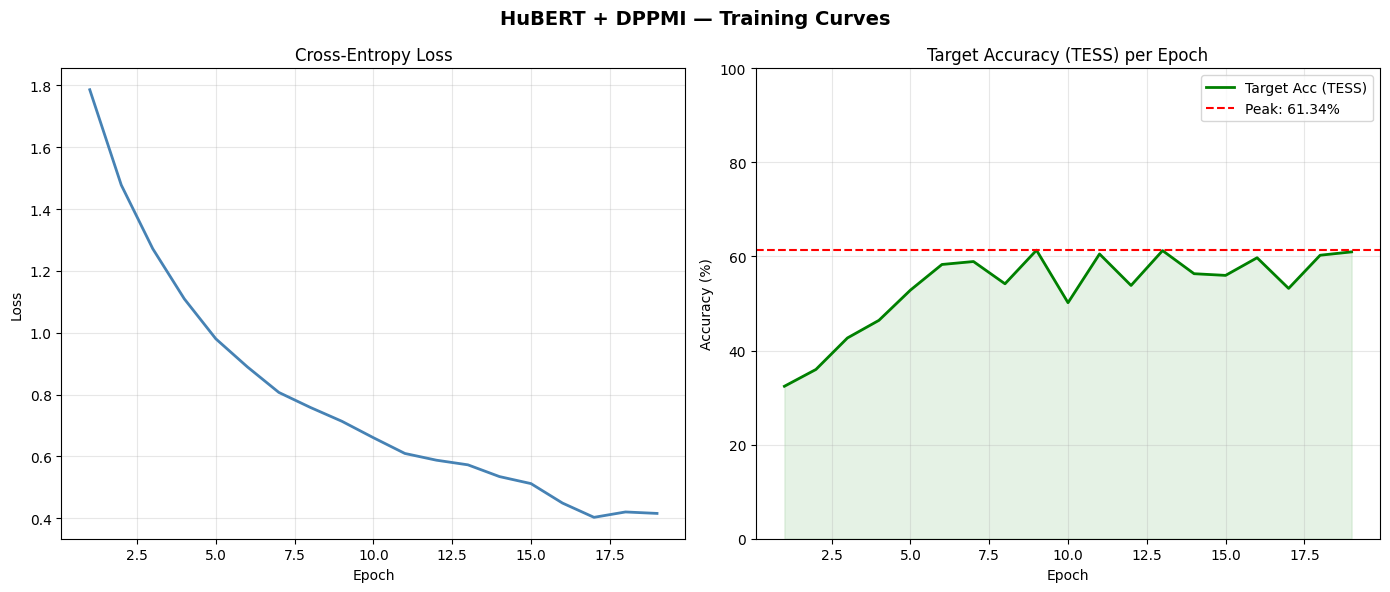

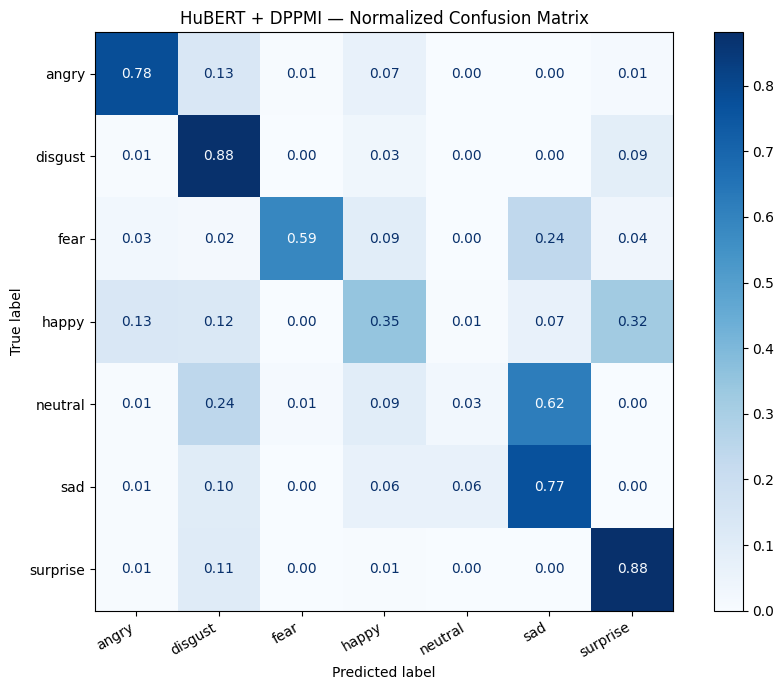

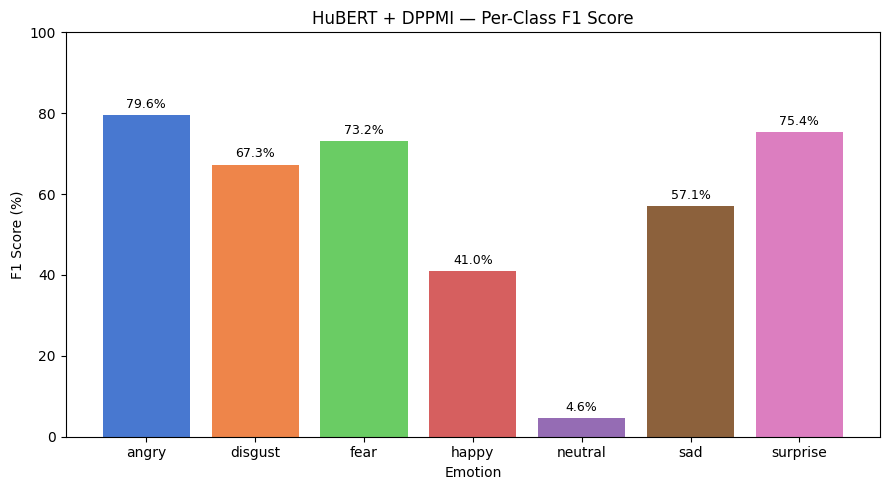

PDF saved: /content/drive/MyDrive/SER_Project/graphs_HuBERT_+_DPPMI.pdf

HuBERT + DPPMI: 61.34%
Saved.
GPU cleared.


In [ ]:
# ── Cell 10: Run 2 — HuBERT + DPPMI ──────────────────────────────────────
import gc

model2, opt2, sch2 = build_model_and_optimizer(
    keep_rate  = BP["keep_rate"],
    unfreeze_n = int(BP["unfreeze_n"]),
    lr_hubert  = BP["lr_hubert"],
    lr_head    = BP["lr_head"]
)

hist2, acc2 = train_model(
    model2, opt2, sch2,
    supcon_loss_fn = None,
    label          = "HuBERT + DPPMI",
    save_name      = "best_hubert_dppmi.pt"
)

_, preds2, labels2 = evaluate(model2, tgt_test_loader)
np.save(SAVE_PATH / "preds_hubert_dppmi.npy", np.array(preds2))

with open(SAVE_PATH / "hist_hubert_dppmi.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in hist2.items()}, f)

with open(SAVE_PATH / "result_hubert_dppmi.json", "w") as f:
    json.dump({"HuBERT + DPPMI": float(acc2)}, f, indent=2)

save_run_graphs(hist2, preds2, labels2, "HuBERT + DPPMI", acc2, SAVE_PATH)

print(f"\nHuBERT + DPPMI: {acc2*100:.2f}%")
print("Saved.")

del model2, opt2, sch2
gc.collect()
torch.cuda.empty_cache()
print("GPU cleared.")

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  HuBERT + DPPMI + SupCon
  Ep |       CE |   SupCon |  Src Acc |  Tgt Acc
-------------------------------------------------------
   1 |   1.7941 |   3.4172 |   38.58% |   37.23%
   2 |   1.4638 |   3.1473 |   50.49% |   46.52%
   3 |   1.2946 |   3.0238 |   58.76% |   70.54%
   4 |   1.1069 |   2.8852 |   64.42% |   77.95%
   5 |   0.9976 |   2.8119 |   71.57% |   78.57%
   6 |   0.8991 |   2.7310 |   75.77% |   84.29%
   7 |   0.8350 |   2.6872 |   76.08% |   82.95%
   8 |   0.7734 |   2.6113 |   77.00% |   87.77%
   9 |   0.7286 |   2.5630 |   76.88% |   86.96%
  10 |   0.6727 |   2.4846 |   79.69% |   89.55%
  11 |   0.6321 |   2.4530 |   76.31% |   90.00%
  12 |   0.5924 |   2.3909 |   82.53% |   96.96%
  13 |   0.5627 |   2.3491 |   78.63% |   94.29%
  14 |   0.5367 |   2.2910 |   87.33% |   97.50%
  15 |   0.5072 |   2.2824 |   87.15% |   98.48%
  16 |   0.4934 |   2.2367 |   86.53% |   96.52%
  17 |   0.4765 |   2.2223 |   88.17% |   96.52%
  18 |   0.4434 |   2.1826 |   87.1

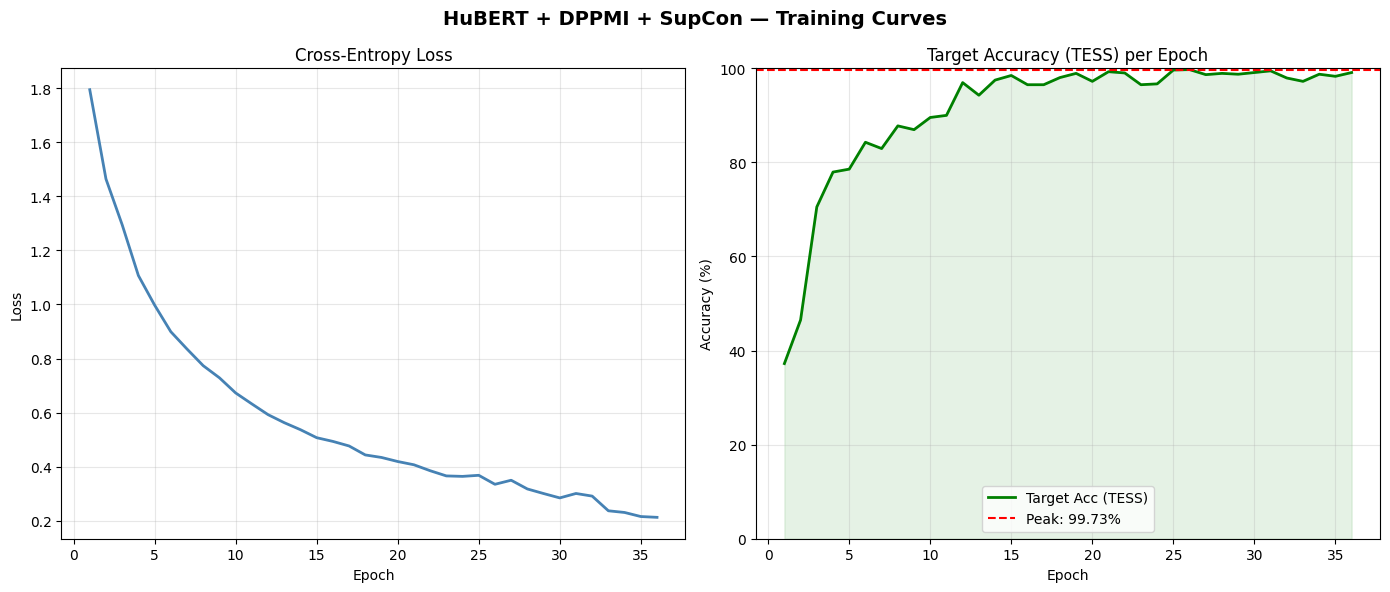

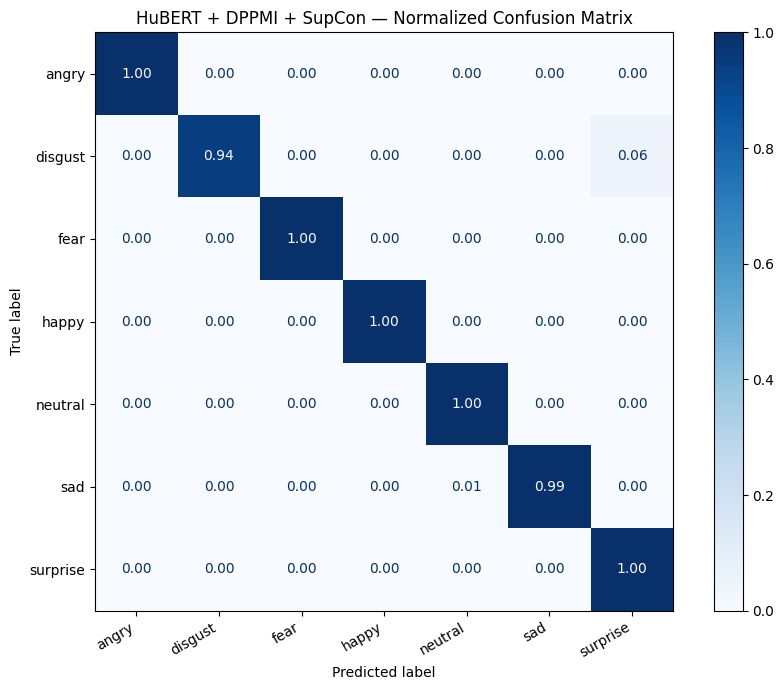

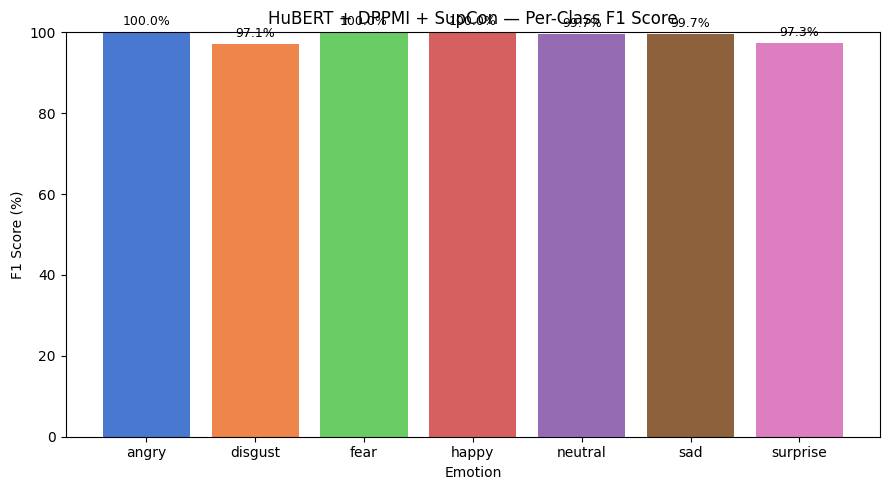

PDF saved: /content/drive/MyDrive/SER_Project/graphs_HuBERT_+_DPPMI_+_SupCon.pdf

HuBERT + DPPMI + SupCon: 99.73%
Saved.
GPU cleared.


In [ ]:
# ── Cell 11: Run 3 — HuBERT + DPPMI + SupCon ─────────────────────────────
import gc

model3, opt3, sch3 = build_model_and_optimizer(
    keep_rate  = BP["keep_rate"],
    unfreeze_n = int(BP["unfreeze_n"]),
    lr_hubert  = BP["lr_hubert"],
    lr_head    = BP["lr_head"]
)
supcon_fn = SupConLoss(temperature=BP["supcon_temp"]).to(DEVICE)

hist3, acc3 = train_model(
    model3, opt3, sch3,
    supcon_loss_fn = supcon_fn,
    lambda_supcon  = BP["lambda_supcon"],
    label          = "HuBERT + DPPMI + SupCon",
    save_name      = "best_full_model.pt"
)

_, preds3, labels3 = evaluate(model3, tgt_test_loader)
np.save(SAVE_PATH / "preds_full_model.npy",  np.array(preds3))
np.save(SAVE_PATH / "labels_test.npy",       np.array(labels3))

with open(SAVE_PATH / "hist_full_model.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in hist3.items()}, f)

with open(SAVE_PATH / "result_full_model.json", "w") as f:
    json.dump({"HuBERT + DPPMI + SupCon": float(acc3)}, f, indent=2)

save_run_graphs(hist3, preds3, labels3, "HuBERT + DPPMI + SupCon", acc3, SAVE_PATH)

print(f"\nHuBERT + DPPMI + SupCon: {acc3*100:.2f}%")
print("Saved.")

del model3, opt3, sch3, supcon_fn
gc.collect()
torch.cuda.empty_cache()
print("GPU cleared.")

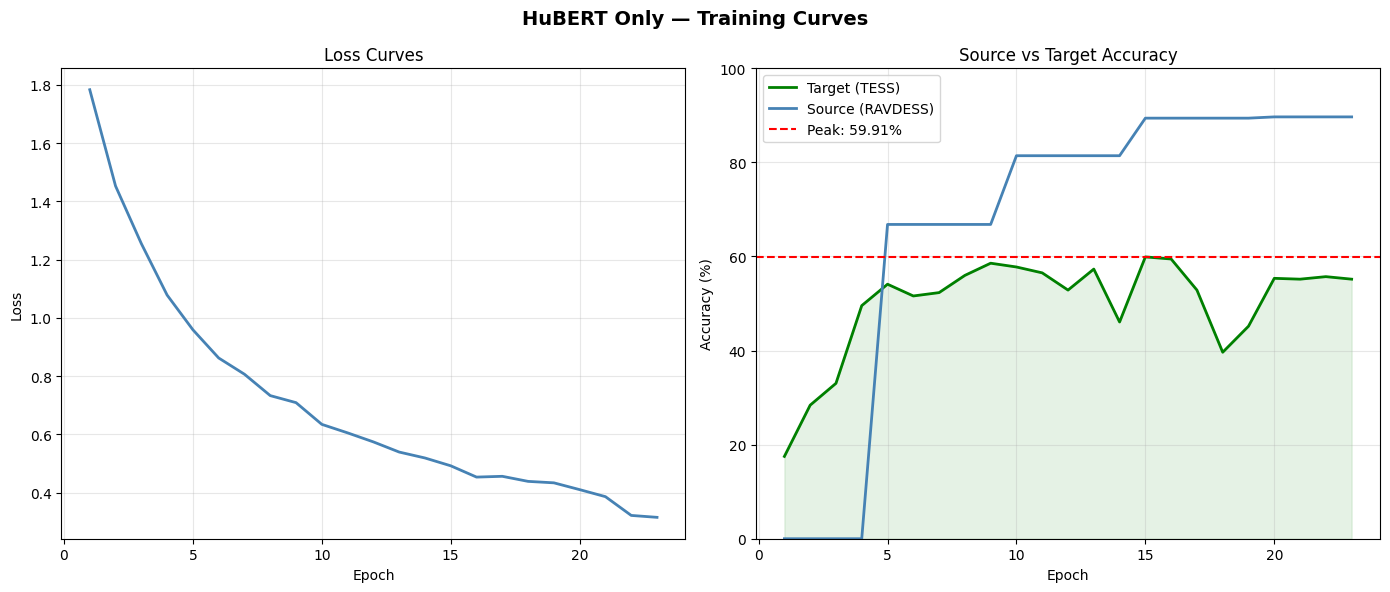

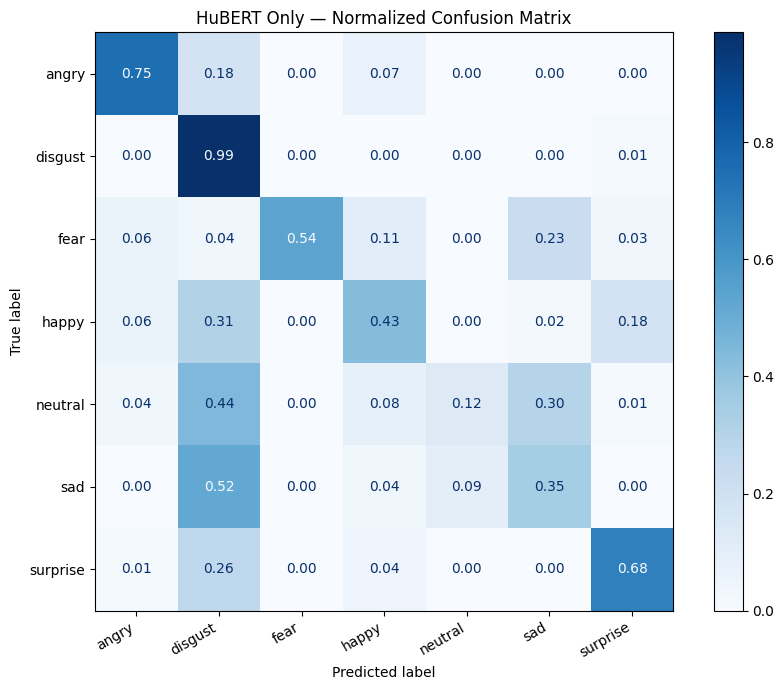

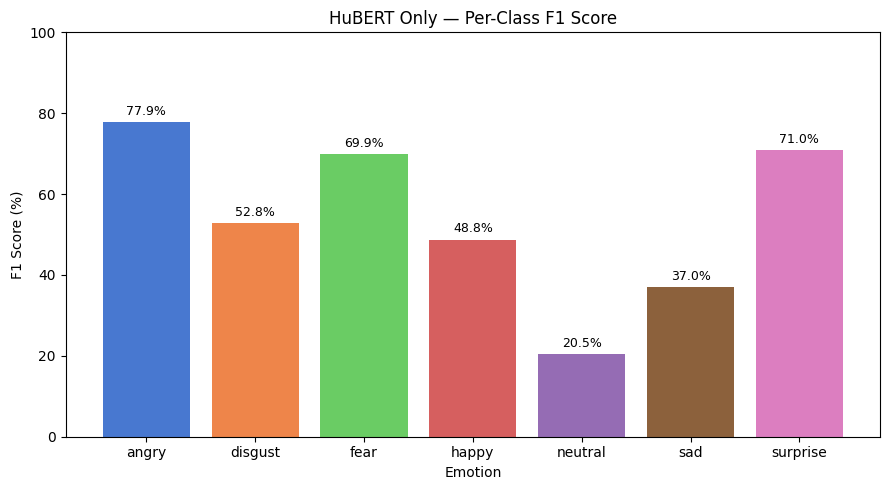

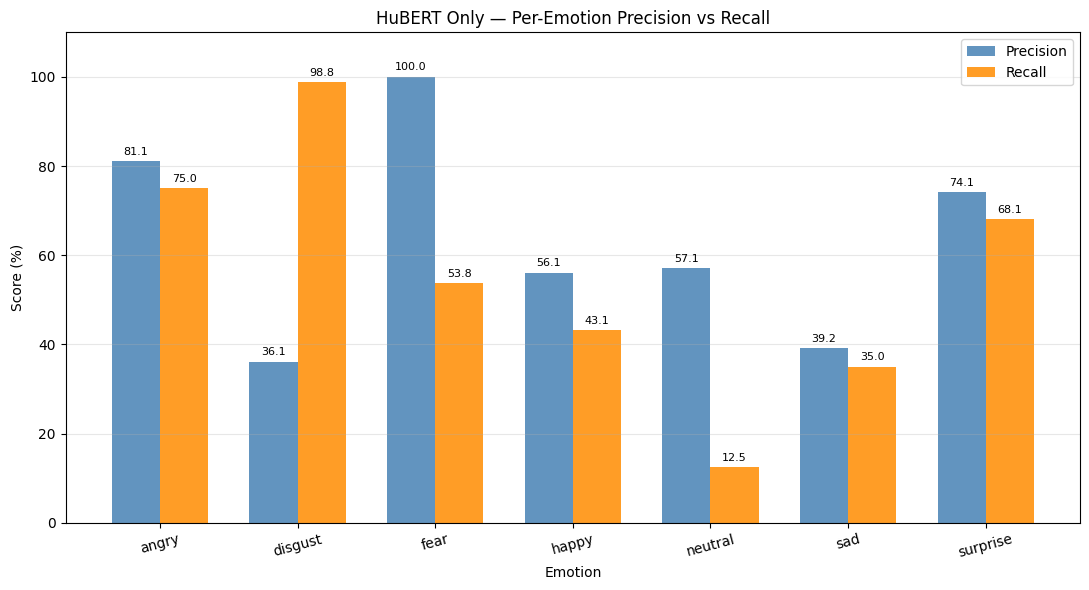

Saved: /content/drive/MyDrive/SER_Project/graphs_HuBERT_Only.pdf


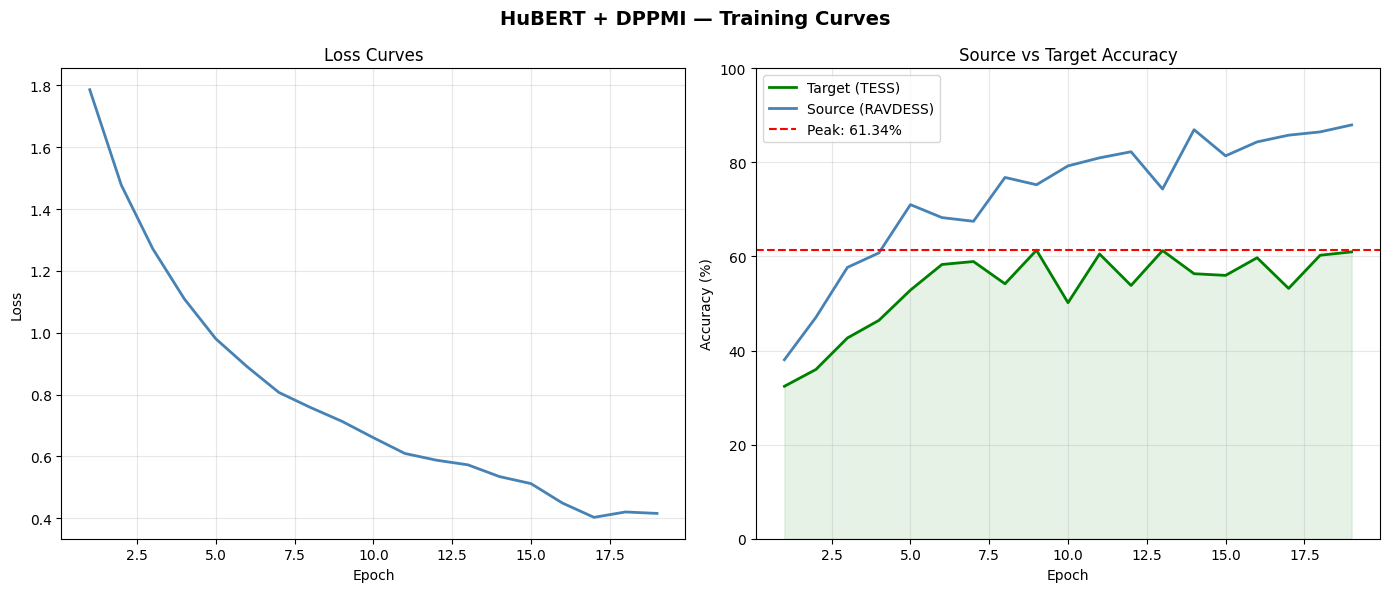

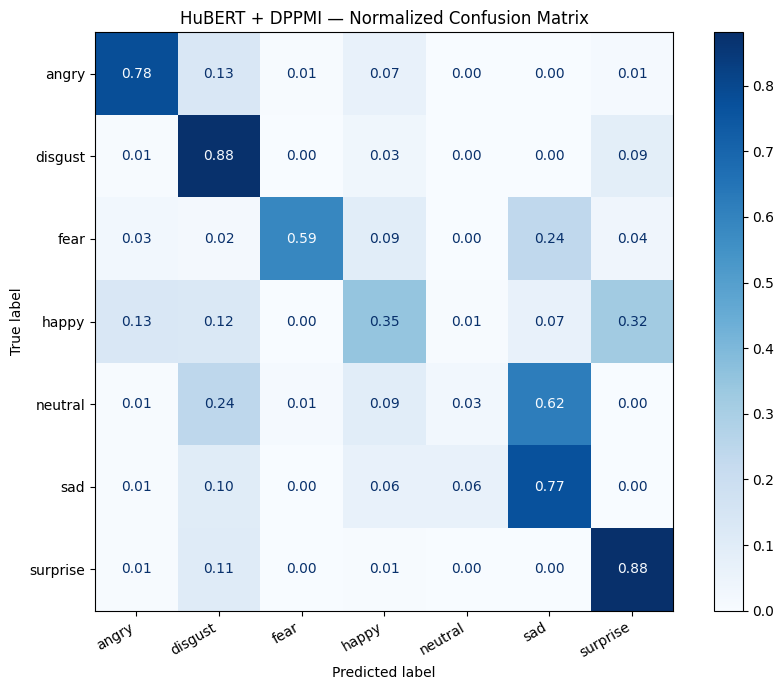

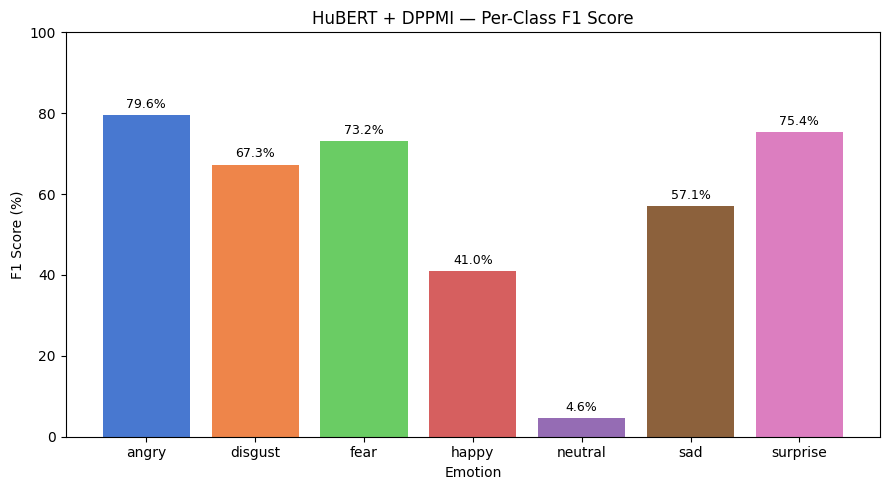

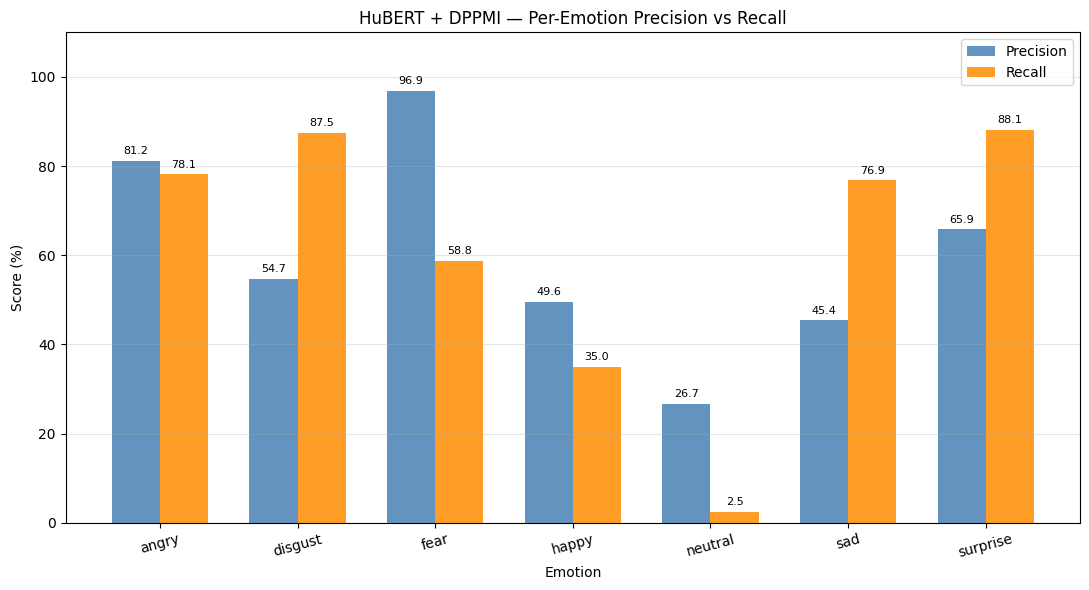

Saved: /content/drive/MyDrive/SER_Project/graphs_HuBERT_+_DPPMI.pdf


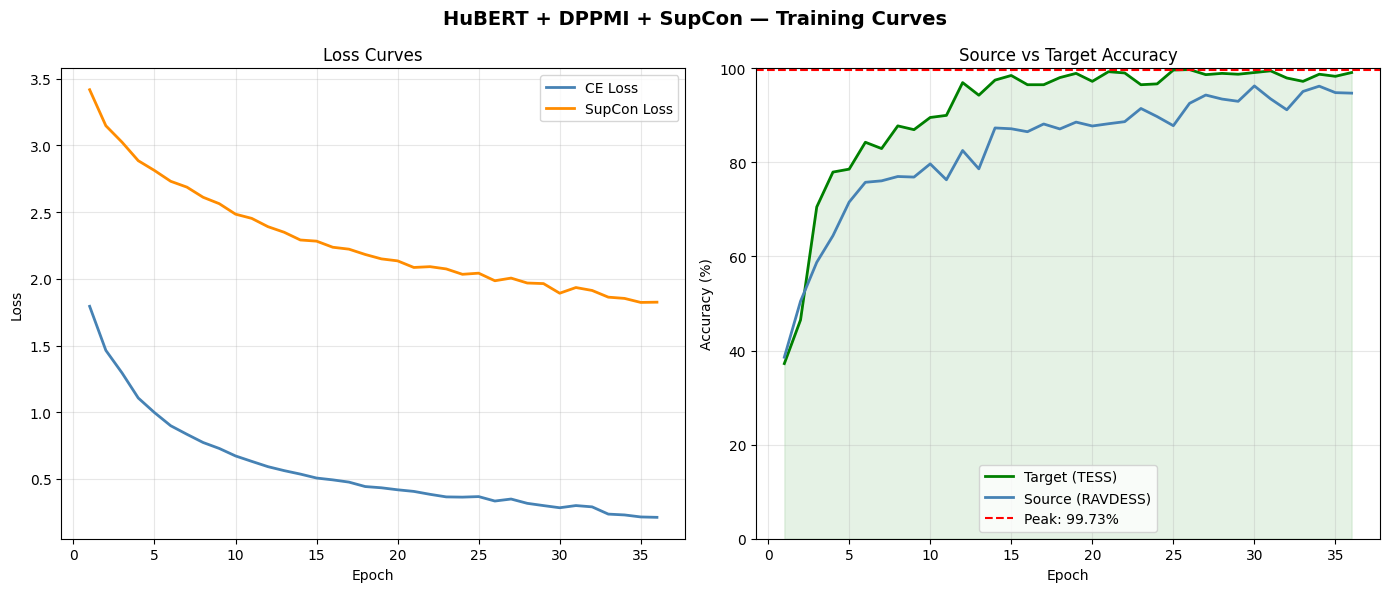

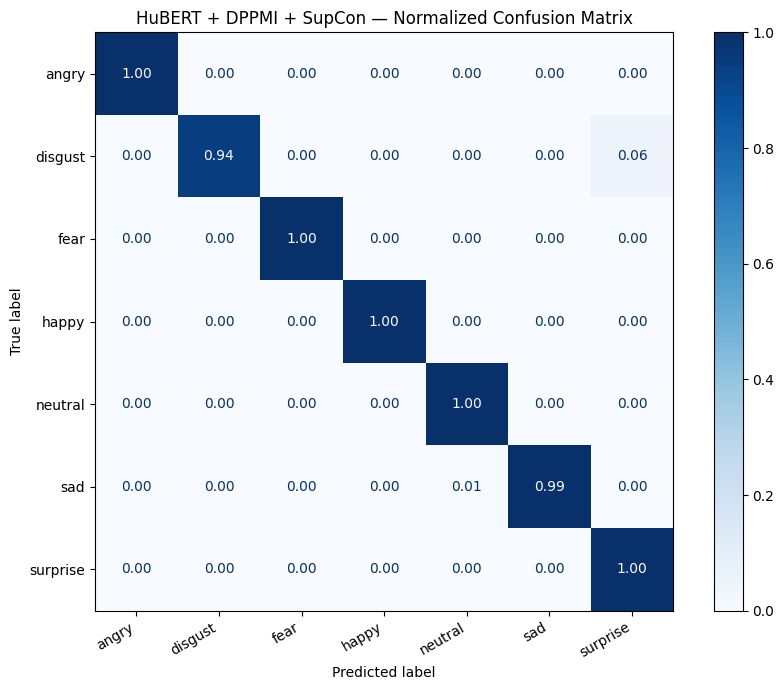

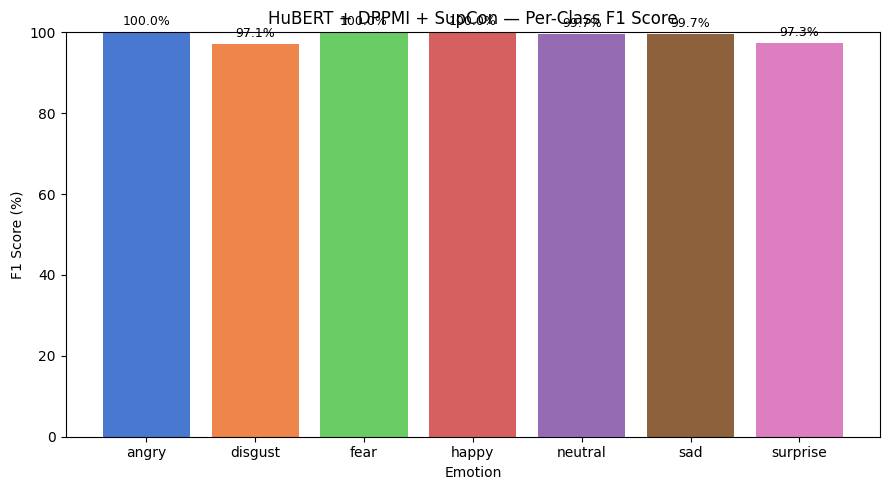

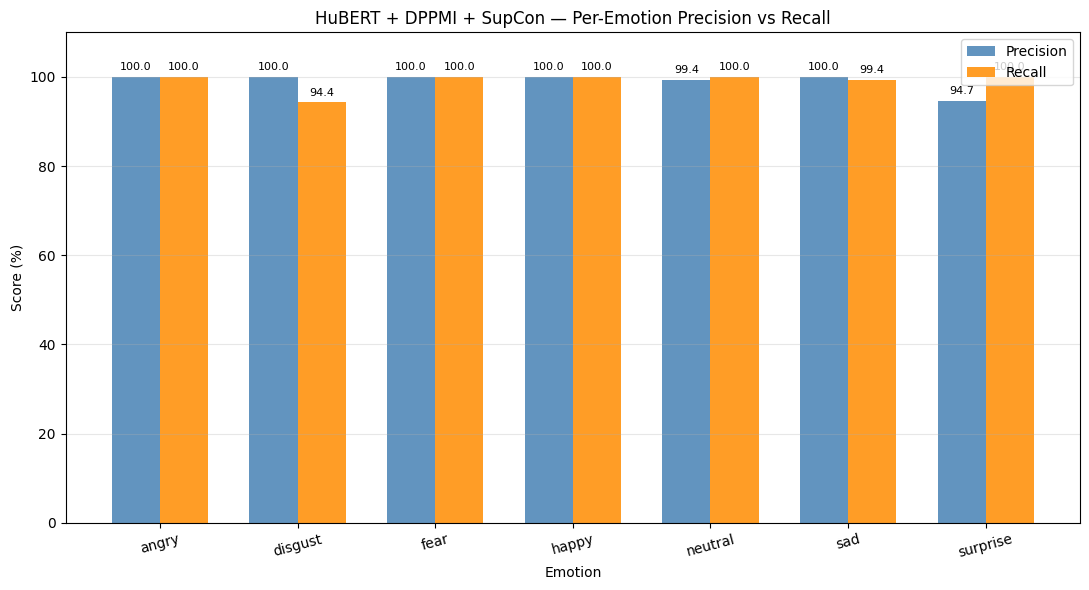

Saved: /content/drive/MyDrive/SER_Project/graphs_HuBERT_+_DPPMI_+_SupCon.pdf
All PDFs generated.


In [ ]:
# ── Final graphs for all 3 runs ────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score
from matplotlib.backends.backend_pdf import PdfPages

def plot_all_graphs(history, preds, labels, run_name, save_path):
    pdf_path = save_path / f"graphs_{run_name.replace(' ', '_')}.pdf"

    with PdfPages(pdf_path) as pdf:

        # Page 1: Training Curves
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle(f"{run_name} — Training Curves", fontsize=14, fontweight="bold")
        epochs = range(1, len(history["ce_loss"]) + 1)
        axes[0].plot(epochs, history["ce_loss"], color="steelblue", linewidth=2, label="CE Loss")
        if any(v > 0 for v in history["supcon_loss"]):
            axes[0].plot(epochs, history["supcon_loss"], color="darkorange", linewidth=2, label="SupCon Loss")
            axes[0].legend()
        axes[0].set_title("Loss Curves")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].grid(True, alpha=0.3)

        tgt = [a*100 for a in history["tgt_acc"]]
        src = []
        last = 0
        for a in history["src_acc"]:
            if a > 0: last = a
            src.append(last * 100)
        axes[1].plot(epochs, tgt, color="green", linewidth=2, label="Target (TESS)")
        axes[1].plot(epochs, src, color="steelblue", linewidth=2, label="Source (RAVDESS)")
        axes[1].fill_between(epochs, tgt, alpha=0.1, color="green")
        axes[1].axhline(y=max(tgt), color="red", linestyle="--", linewidth=1.5,
                        label=f"Peak: {max(tgt):.2f}%")
        axes[1].set_title("Source vs Target Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy (%)")
        axes[1].set_ylim(0, 100)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

        # Page 2: Confusion Matrix
        fig, ax = plt.subplots(figsize=(9, 7))
        cm = confusion_matrix(labels, preds, normalize="true")
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
        disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format=".2f")
        ax.set_title(f"{run_name} — Normalized Confusion Matrix")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

        # Page 3: Per-Class F1
        f1s = f1_score(labels, preds, average=None)
        fig, ax = plt.subplots(figsize=(9, 5))
        bars = ax.bar(CLASS_LABELS, f1s * 100, color=sns.color_palette("muted", NUM_CLASSES))
        ax.set_title(f"{run_name} — Per-Class F1 Score")
        ax.set_xlabel("Emotion")
        ax.set_ylabel("F1 Score (%)")
        ax.set_ylim(0, 100)
        for bar, f1 in zip(bars, f1s):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{f1*100:.1f}%", ha="center", va="bottom", fontsize=9)
        plt.tight_layout()
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

        # Page 4: Classification Report
        report = classification_report(labels, preds, target_names=CLASS_LABELS, digits=3)
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.axis("off")
        ax.text(0.01, 0.99, f"{run_name}\nClassification Report\n\n{report}",
                transform=ax.transAxes, fontsize=10,
                verticalalignment="top", fontfamily="monospace")
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.close()

        # Page 5: Per-Emotion Precision vs Recall
        precision = precision_score(labels, preds, average=None, zero_division=0)
        recall    = recall_score(labels, preds, average=None, zero_division=0)
        x     = np.arange(len(CLASS_LABELS))
        width = 0.35
        fig, ax = plt.subplots(figsize=(11, 6))
        bars1 = ax.bar(x - width/2, precision * 100, width,
                       label="Precision", color="steelblue", alpha=0.85)
        bars2 = ax.bar(x + width/2, recall * 100, width,
                       label="Recall", color="darkorange", alpha=0.85)
        ax.set_title(f"{run_name} — Per-Emotion Precision vs Recall")
        ax.set_xlabel("Emotion")
        ax.set_ylabel("Score (%)")
        ax.set_ylim(0, 110)
        ax.set_xticks(x)
        ax.set_xticklabels(CLASS_LABELS, rotation=15)
        ax.legend()
        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)
        ax.grid(True, alpha=0.3, axis="y")
        plt.tight_layout()
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    print(f"Saved: {pdf_path}")


# ── Generate for all 3 runs ────────────────────────────────────────────────
plot_all_graphs(hist1, preds1, labels1, "HuBERT Only",             SAVE_PATH)
plot_all_graphs(hist2, preds2, labels2, "HuBERT + DPPMI",          SAVE_PATH)
plot_all_graphs(hist3, preds3, labels3, "HuBERT + DPPMI + SupCon", SAVE_PATH)
print("All PDFs generated.")

In [ ]:
import json
import numpy as np

acc1 = json.load(open(SAVE_PATH / "result_hubert_only.json"))["HuBERT Only"]
acc2 = json.load(open(SAVE_PATH / "result_hubert_dppmi.json"))["HuBERT + DPPMI"]
hist1 = json.load(open(SAVE_PATH / "hist_hubert_only.json"))
hist2 = json.load(open(SAVE_PATH / "hist_hubert_dppmi.json"))
preds1 = np.load(SAVE_PATH / "preds_hubert_only.npy")
preds2 = np.load(SAVE_PATH / "preds_hubert_dppmi.npy")
labels1 = np.load(SAVE_PATH / "labels_test.npy")
print(f"HuBERT Only    : {acc1*100:.2f}%")
print(f"HuBERT + DPPMI : {acc2*100:.2f}%")

HuBERT Only    : 56.61%
HuBERT + DPPMI : 61.34%


In [ ]:
# ── Cell 11: Run 3 — HuBERT + DPPMI + SupCon ─────────────────────────────
import gc

model3, opt3, sch3 = build_model_and_optimizer(
    keep_rate  = BP["keep_rate"],
    unfreeze_n = int(BP["unfreeze_n"]),
    lr_hubert  = BP["lr_hubert"],
    lr_head    = BP["lr_head"]
)
supcon_fn = SupConLoss(temperature=BP["supcon_temp"]).to(DEVICE)

hist3, acc3 = train_model(
    model3, opt3, sch3,
    supcon_loss_fn = supcon_fn,
    lambda_supcon  = BP["lambda_supcon"],
    label          = "HuBERT + DPPMI + SupCon",
    save_name      = "best_full_model.pt"
)

_, preds3, labels3 = evaluate(model3, tgt_test_loader)
np.save(SAVE_PATH / "preds_full_model.npy",  np.array(preds3))
np.save(SAVE_PATH / "labels_test.npy",       np.array(labels3))

with open(SAVE_PATH / "hist_full_model.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in hist3.items()}, f)

with open(SAVE_PATH / "result_full_model.json", "w") as f:
    json.dump({"HuBERT + DPPMI + SupCon": float(acc3)}, f, indent=2)

save_run_graphs(hist3, preds3, labels3, "HuBERT + DPPMI + SupCon", acc3, SAVE_PATH)

print(f"\nHuBERT + DPPMI + SupCon: {acc3*100:.2f}%")
print("Saved.")

del model3, opt3, sch3, supcon_fn
gc.collect()
torch.cuda.empty_cache()
print("GPU cleared.")

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.bias   | UNEXPECTED |  | 
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  HuBERT + DPPMI + SupCon
  Ep |       CE |   SupCon |  Src Acc |  Tgt Acc
-------------------------------------------------------
   1 |   1.8062 |   2.4181 |   39.60% |   27.32%
   2 |   1.4963 |   2.2814 |   49.07% |   33.75%
   3 |   1.3421 |   2.1906 |   54.47% |   36.43%
   4 |   1.1827 |   2.1096 |   65.04% |   50.00%
   5 |   1.0499 |   2.0284 |   65.33% |   53.93%
   6 |   0.9347 |   1.9772 |   70.05% |   56.52%
   7 |   0.8303 |   1.9271 |   69.07% |   55.00%
   8 |   0.7618 |   1.8827 |   69.75% |   56.79%
   9 |   0.7112 |   1.8120 |   79.89% |   57.95%
  10 |   0.6622 |   1.7843 |   81.29% |   55.80%
  11 |   0.6213 |   1.7498 |   82.72% |   50.54%
  12 |   0.6031 |   1.7200 |   87.89% |   59.20%
  13 |   0.5620 |   1.6621 |   84.88% |   60.62%
  14 |   0.5315 |   1.6511 |   87.70% |   56.88%
  15 |   0.5176 |   1.6308 |   86.43% |   60.62%
  16 |   0.4845 |   1.5820 |   88.49% |   61.07%
  17 |   0.4721 |   1.5501 |   87.97% |   61.16%
  18 |   0.4481 |   1.5183 |   90.3

NameError: name 'save_run_graphs' is not defined

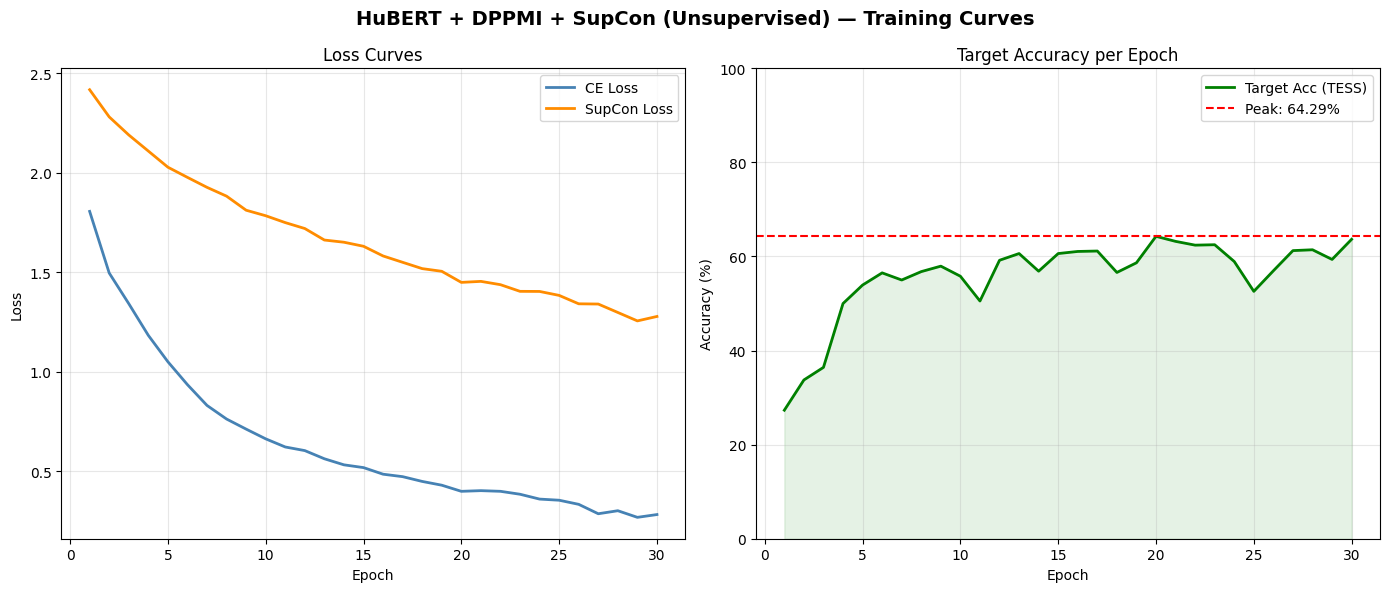

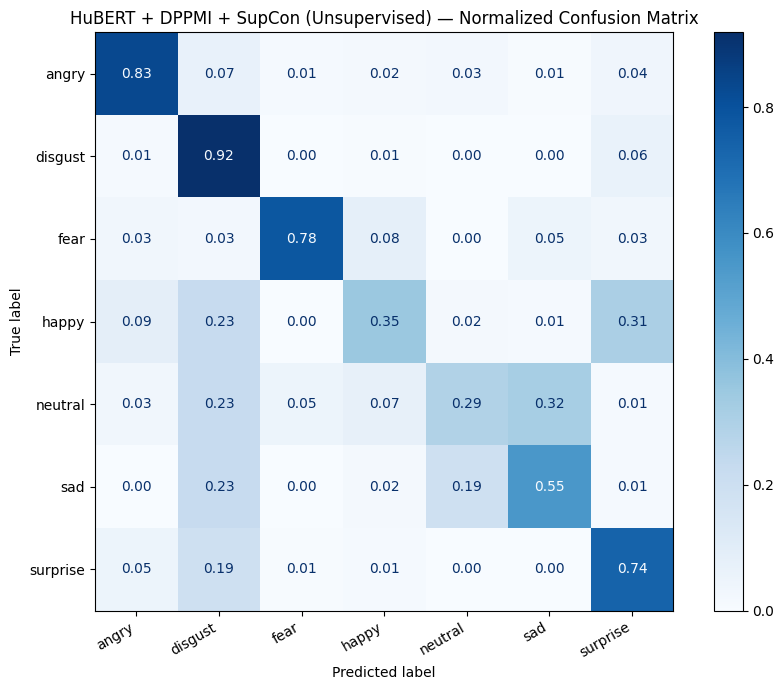

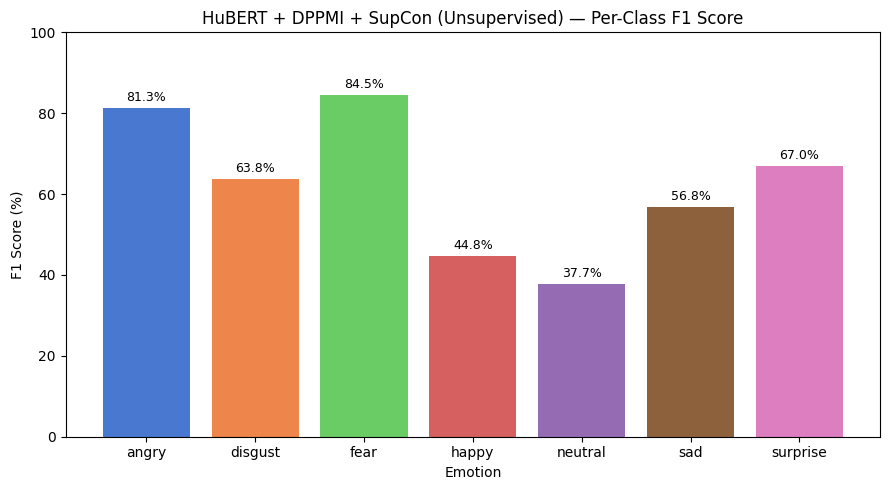

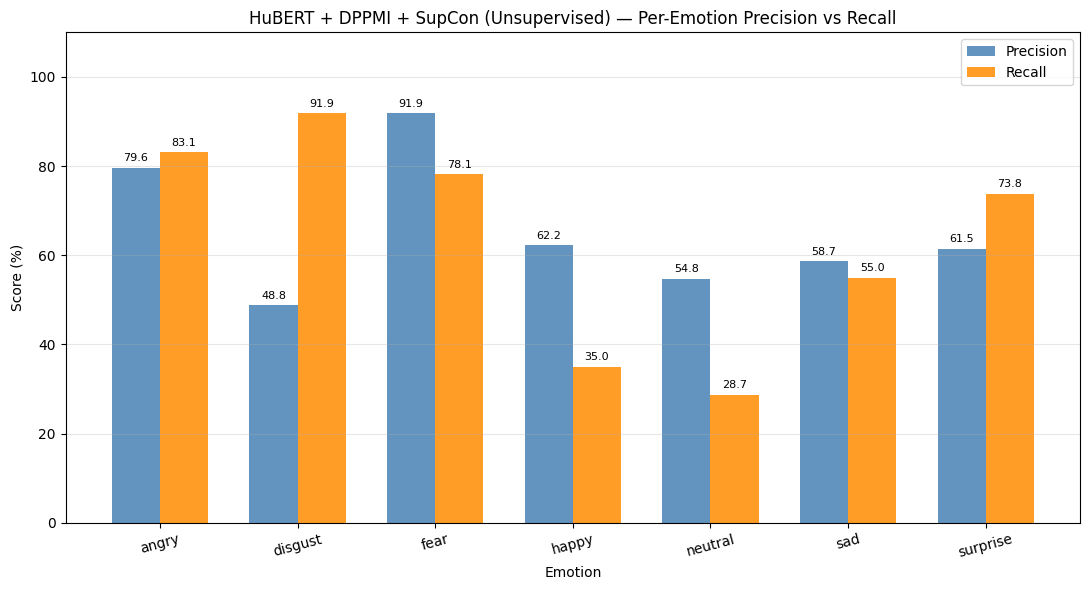

PDF saved: /content/drive/MyDrive/SER_Project/graphs_HuBERT_+_DPPMI_+_SupCon_(Unsupervised).pdf


In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import precision_score, recall_score

def save_run_graphs(history, preds, labels, run_name, best_acc, save_path):
    pdf_path = save_path / f"graphs_{run_name.replace(' ', '_')}.pdf"
    with PdfPages(pdf_path) as pdf:
        epochs = range(1, len(history["ce_loss"]) + 1)

        # Page 1: Training Curves
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle(f"{run_name} — Training Curves", fontsize=14, fontweight="bold")
        axes[0].plot(epochs, history["ce_loss"], color="steelblue", linewidth=2, label="CE Loss")
        if any(v > 0 for v in history["supcon_loss"]):
            axes[0].plot(epochs, history["supcon_loss"], color="darkorange", linewidth=2, label="SupCon Loss")
            axes[0].legend()
        axes[0].set_title("Loss Curves")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].grid(True, alpha=0.3)
        tgt = [a*100 for a in history["tgt_acc"]]
        axes[1].plot(epochs, tgt, color="green", linewidth=2, label="Target Acc (TESS)")
        axes[1].fill_between(epochs, tgt, alpha=0.1, color="green")
        axes[1].axhline(y=max(tgt), color="red", linestyle="--", linewidth=1.5,
                        label=f"Peak: {max(tgt):.2f}%")
        axes[1].set_title("Target Accuracy per Epoch")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy (%)")
        axes[1].set_ylim(0, 100)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

        # Page 2: Confusion Matrix
        fig, ax = plt.subplots(figsize=(9, 7))
        cm = confusion_matrix(labels, preds, normalize="true")
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
        disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format=".2f")
        ax.set_title(f"{run_name} — Normalized Confusion Matrix")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

        # Page 3: Per-Class F1
        f1s = f1_score(labels, preds, average=None)
        fig, ax = plt.subplots(figsize=(9, 5))
        bars = ax.bar(CLASS_LABELS, f1s * 100, color=sns.color_palette("muted", NUM_CLASSES))
        ax.set_title(f"{run_name} — Per-Class F1 Score")
        ax.set_xlabel("Emotion")
        ax.set_ylabel("F1 Score (%)")
        ax.set_ylim(0, 100)
        for bar, f1 in zip(bars, f1s):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{f1*100:.1f}%", ha="center", va="bottom", fontsize=9)
        plt.tight_layout()
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

        # Page 4: Classification Report
        report = classification_report(labels, preds, target_names=CLASS_LABELS, digits=3)
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.axis("off")
        ax.text(0.01, 0.99, f"{run_name}\nClassification Report\n\n{report}",
                transform=ax.transAxes, fontsize=10,
                verticalalignment="top", fontfamily="monospace")
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.close()

        # Page 5: Per-Emotion Precision vs Recall
        precision = precision_score(labels, preds, average=None, zero_division=0)
        recall    = recall_score(labels, preds, average=None, zero_division=0)
        x = np.arange(len(CLASS_LABELS))
        width = 0.35
        fig, ax = plt.subplots(figsize=(11, 6))
        bars1 = ax.bar(x - width/2, precision * 100, width, label="Precision", color="steelblue", alpha=0.85)
        bars2 = ax.bar(x + width/2, recall * 100, width, label="Recall", color="darkorange", alpha=0.85)
        ax.set_title(f"{run_name} — Per-Emotion Precision vs Recall")
        ax.set_xlabel("Emotion")
        ax.set_ylabel("Score (%)")
        ax.set_ylim(0, 110)
        ax.set_xticks(x)
        ax.set_xticklabels(CLASS_LABELS, rotation=15)
        ax.legend()
        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)
        ax.grid(True, alpha=0.3, axis="y")
        plt.tight_layout()
        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    print(f"PDF saved: {pdf_path}")

# Generate graphs for Run 3
save_run_graphs(hist3, preds3, labels3, "HuBERT + DPPMI + SupCon (Unsupervised)", acc3, SAVE_PATH)